# ML2_Supervised learning

## 1. Ответы на вопросы

### **1.1 Аналитическое решение Линейной регрессии**

### **Векторная форма*

Матрица признаков: $X \in \mathbb{R}^{n \times d}$  
Целевой признак: $y \in \mathbb{R}^n$  
Веса: $w \in \mathbb{R}^d$
**Модель**: $\hat{y} = Xw$

Решение Линейной регресси заключается в поиске такой матрицы весов w, чтобы ошибка была мнимальной
$$MSE = \frac{1}{n} \sum_{i=1}^{n} (y_i - Xw)^2$$
$$LogLoss = -\frac{1}{n} \sum_{i=1}^{n} [y_i \ln(p_i) + (1 - y_i) \ln(1 - p_i)]$$
, где $$p_i = \frac{1}{1+e^{z}}$$ - сигмоида от предикта $$z = w^{T}x +b$$

**Аналитическое решение (нормальное уравние)**:
Наша квадратичная сумма потерь равна
$$ L(w) =  ||Xw-y||^2$$
Чтобы наша модель была точной нужно ее минимизировать или найти $w$ при котором производная $L(w) = 0$, поэтому приводим её к квадртичному виду таким образом
$$ L(w) = (Xw-y)^{T}(Xw-y) $$
Раскрыв скобки получаем
$$ L(w) = X^{T}w^{T}Xw-X^{T}w^{T}y - Xwy^{T} +y^{T}y  $$
Берем производную
$$ \nabla{L(w)} = 2*X^{T}Xw-2X^{T}y $$

Точка минимума при $ \nabla{L(w)} = 0 $ =>
$$ X^{T}Xw = 2X^{T}y $$
=>
$$ w =(X^{T}X)^{-1} X^{T}y $$

### **1.2 Что меняется в решении, когда к функции потерь добавляются регуляризации L1 и L2.**
Регуляризация при каждой итераиции поиска весов добавляет "штраф" за точность, чтобы избежать переобучения

### **L2 (Ridge)**
L2 добавляет пенальти к большим веса, но не зануляет их полностью:
$$ \mathcal{L}_{\text{ridge}}(w) = \|Xw - y\|^2 + {\lambda}\|w\|_2^2 $$

**L2 в аналитическом решении**:
$$ \hat{w}_{\text{Ridge}} = (X^\top X + \lambda I)^{-1} X^\top y $$

**При L2 градиент будет выглядить так:**:
$$ \nabla{L(w)}= 2X^{T}(Xw-y)+2\lambda w$$
А сам градентный спуск будет выглядить таким образом:
$$ w_{t+1} = w_t(1-2\nu\lambda) - 2\nu X^{T}(Xw-y) $$

**Параметры**:
1. Шаг регуляризации $\lambda I$ в матрицу $X^\top X$
2. Матрица всегда обратима
3. Пропорциональное сокращениев весов  $\lambda$

### **L1 (Lasso)**
Добавление суммы абсолютных весов:
$$ L_{\text{Lasso}}(w) = \|Xw - y\|^2 + \lambda\|w\|_1 $$
где $\|w\|_1 = \sum_i |w_i|$ 

**Свойства**:
1. Нет решения в аналитической решении и градиентном спске
2. Плохо подходит для градиентного спуска, однако может использоваться в координатном спуске или в L-BFGS
3. Может обнулить веса ( $w_i = 0$), если они меньше $\lambda$

### **1.3 Почему после подгонки модели многие веса равны 0?**
### **Геометрическое объяснение**
Минимизируем $L(w)$ для $\|w\|_1 \leq t$:

- **L2 огрраниечение**: круг → решение обычно находится в пределах круга → ненулевые векторы
- **L1 огрраниечение**: ромб → решения находятся на **углах** → некоторые координаты = 0

### **Математическое объяснение**
Оптимальное решение (супградиент):
$$ X_j^\top(y - Xw) = \lambda \cdot \text{sign}(w_j) \quad \text{if } w_j \neq 0 $$
$$ |X_j^\top(y - Xw)| \leq \lambda \quad \text{if } w_j = 0 $$

**Вывод**: веса $w_j$ становятся нулевыми если их корреляция с таргетом меньше $\lambda$.

### **1.4 Как моделировать нелинейности с помощью линейных моделей**
### **Идея**

Модель остается **линейной по параметрам**, но ** нелинейной по характеристикам**.

**Подход:**
Замените исходные характеристики $x$ нелинейными функциями:
$$ \phi(x) = [x, x^2, x^3, \sin x, \log x, \dots] $$

**Модель:**
$$ \hat{y} = w^\top \phi(x) $$

**Примеры:**
- Полиномиальная регрессия
- Особенности взаимодействия
- Логарифмические преобразования
- Объединение признаков

### ** Почему это работает**
- Линейно по весам $w$
- Нелинейно по исходному пространству признаков

### **Опасность**
- Высокий риск переобучения
- Почти всегда требуется регуляризация

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet, SGDRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler

import re
from collections import Counter
from numba import njit 

In [2]:
from my_metrics import get_metrics, my_pipeline
from my_models import LinearRegressionAnalytic, LinearRegressionGradient, LinearRegressionSGD
from my_reg import RidgeGD, LassoGD, ElasticNetGD
from my_preprocesing import My_MinMaxScaler, My_StandartScaler

In [3]:
d_train = pd.read_json('./data/train.json')
d_test = pd.read_json('./data/test.json')

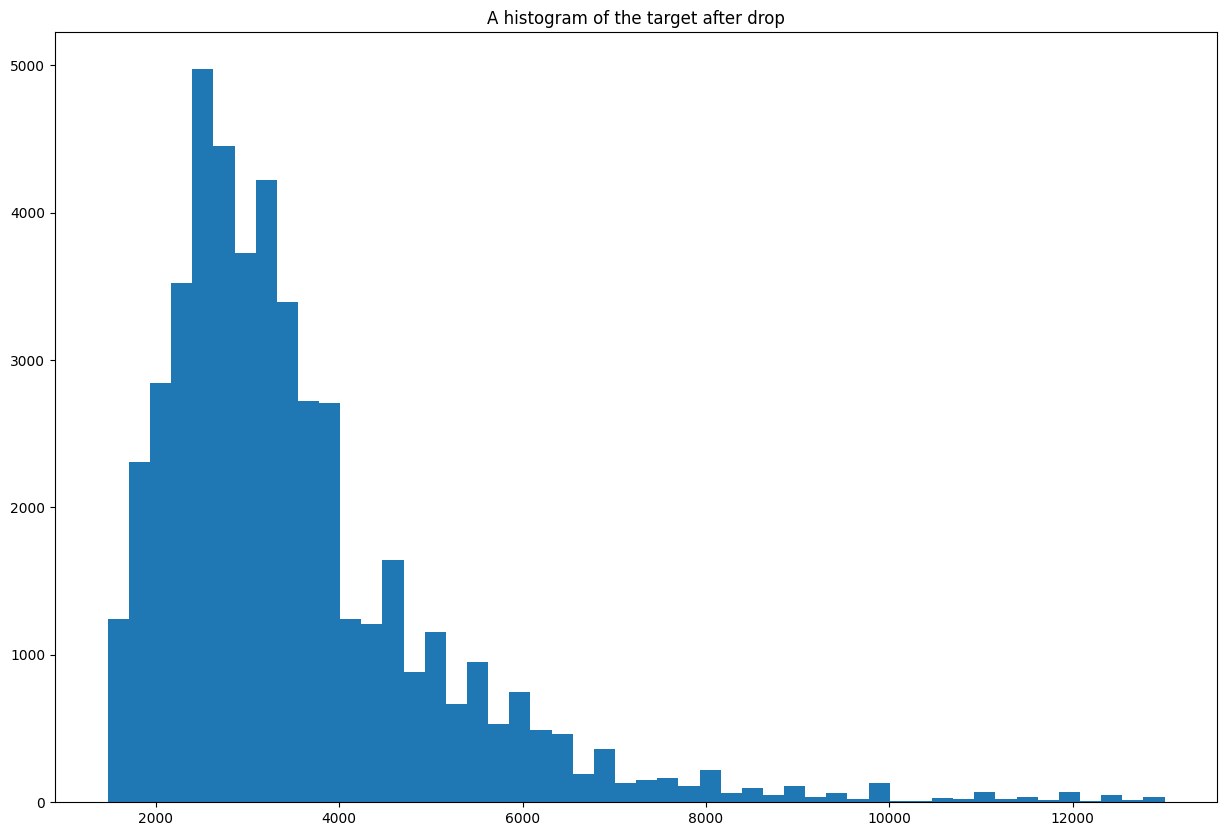

In [4]:
percentile_1 = np.percentile(d_train['price'], 1)
percentile_99 = np.percentile(d_train['price'], 99)
d_train = d_train[(d_train['price'] >= percentile_1) & (d_train['price'] <= percentile_99)].copy()
plt.figure(figsize=(15, 10))
plt.hist(d_train['price'], bins=50)
plt.title('A histogram of the target after drop')
plt.show() 

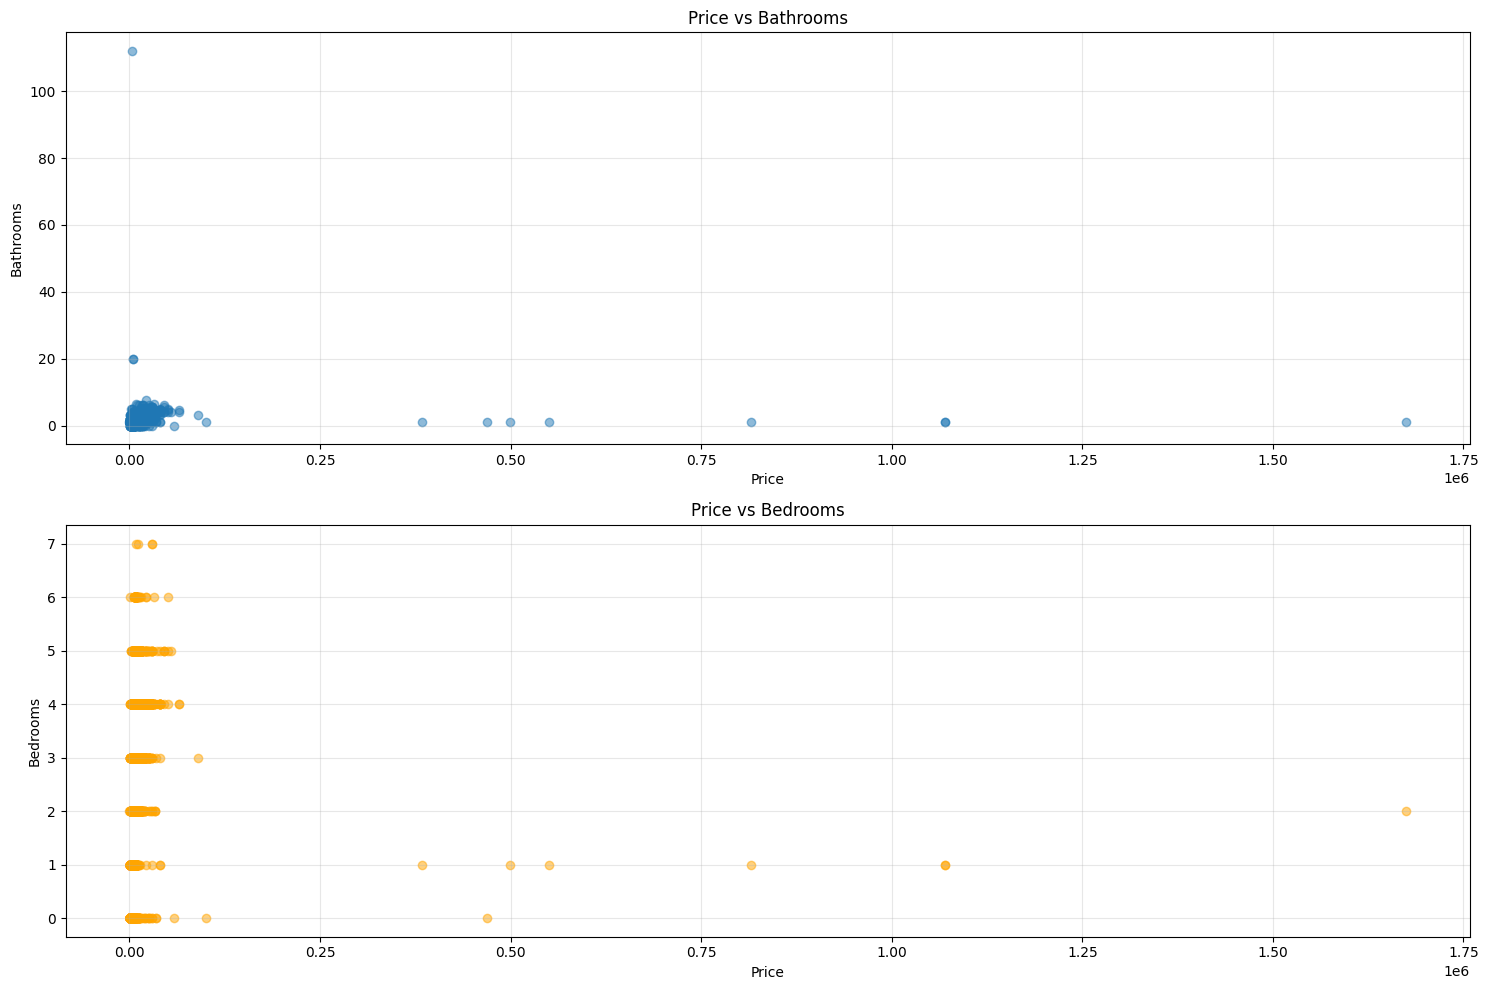

In [5]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 10))

ax1.scatter(d_test['price'], d_test['bathrooms'], alpha=0.5)
ax1.set_xlabel('Price')
ax1.set_ylabel('Bathrooms')
ax1.set_title('Price vs Bathrooms')
ax1.grid(True, alpha=0.3)

ax2.scatter(d_test['price'], d_test['bedrooms'], alpha=0.5, color='orange')
ax2.set_xlabel('Price')
ax2.set_ylabel('Bedrooms')
ax2.set_title('Price vs Bedrooms')
ax2.grid(True, alpha=0.3)


plt.tight_layout()
plt.show()

In [6]:
percentile_1 = np.percentile(d_test['price'], 1)
percentile_99 = np.percentile(d_test['price'], 99)
d_test = d_test[(d_test['price'] >= percentile_1) & (d_test['price'] <= percentile_99)].copy()
d_test = d_test[(d_test['bathrooms'] < 20)].copy()

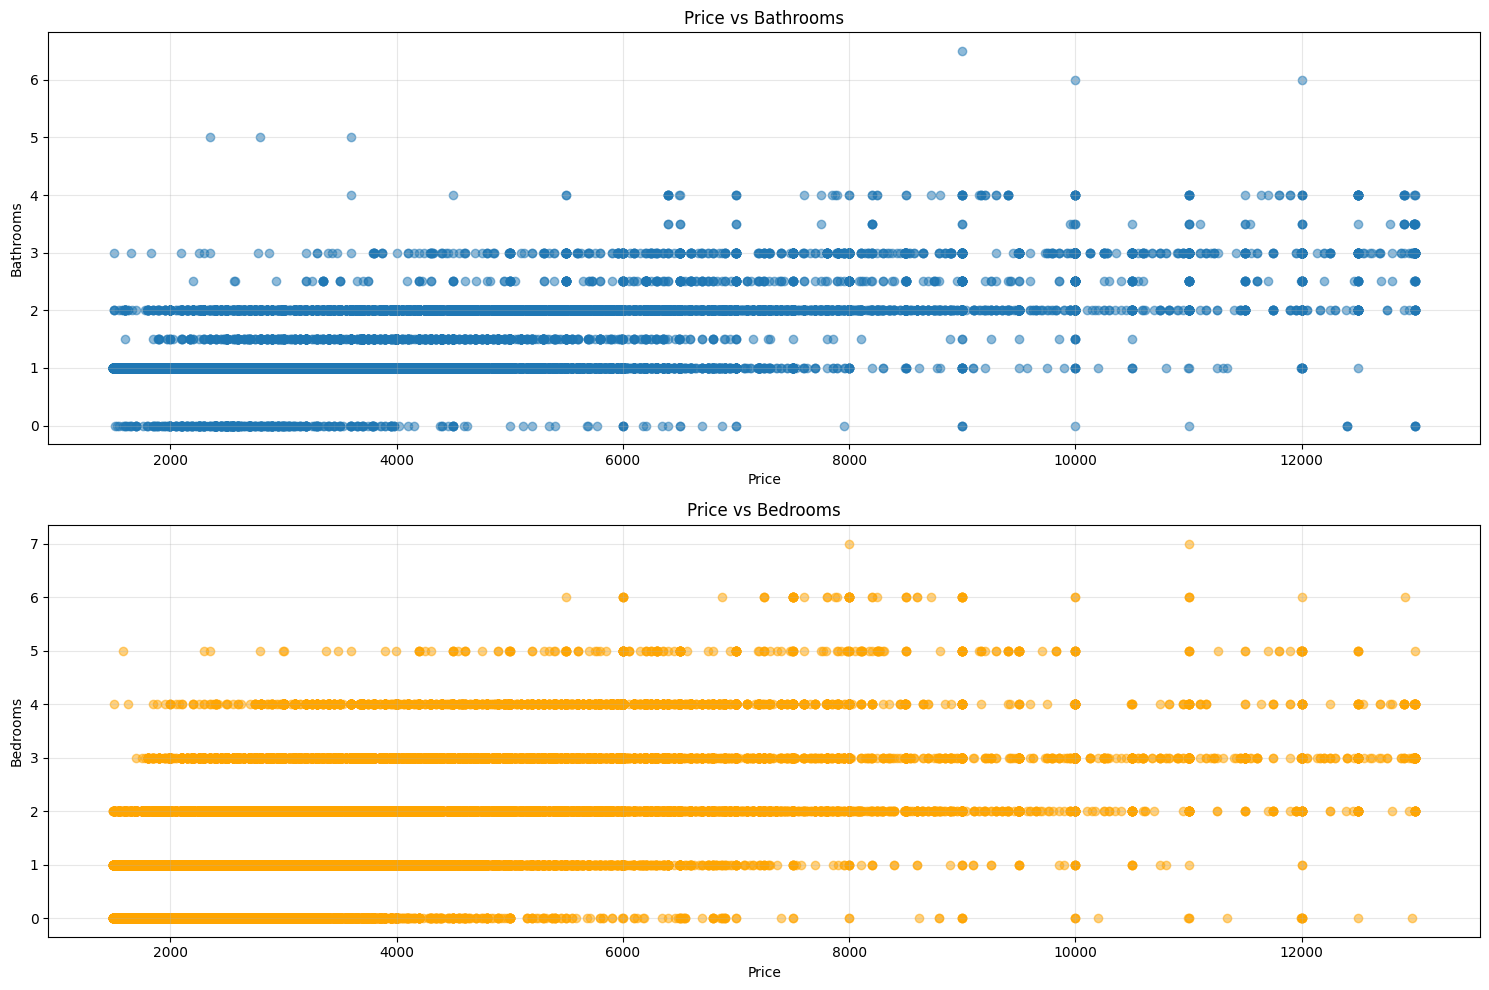

In [7]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 10))

ax1.scatter(d_test['price'], d_test['bathrooms'], alpha=0.5)
ax1.set_xlabel('Price')
ax1.set_ylabel('Bathrooms')
ax1.set_title('Price vs Bathrooms')
ax1.grid(True, alpha=0.3)

ax2.scatter(d_test['price'], d_test['bedrooms'], alpha=0.5, color='orange')
ax2.set_xlabel('Price')
ax2.set_ylabel('Bedrooms')
ax2.set_title('Price vs Bedrooms')
ax2.grid(True, alpha=0.3)


plt.tight_layout()
plt.show()

In [8]:
d_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 48379 entries, 4 to 124009
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   bathrooms        48379 non-null  float64
 1   bedrooms         48379 non-null  int64  
 2   building_id      48379 non-null  object 
 3   created          48379 non-null  object 
 4   description      48379 non-null  object 
 5   display_address  48379 non-null  object 
 6   features         48379 non-null  object 
 7   latitude         48379 non-null  float64
 8   listing_id       48379 non-null  int64  
 9   longitude        48379 non-null  float64
 10  manager_id       48379 non-null  object 
 11  photos           48379 non-null  object 
 12  price            48379 non-null  int64  
 13  street_address   48379 non-null  object 
 14  interest_level   48379 non-null  object 
dtypes: float64(3), int64(3), object(9)
memory usage: 5.9+ MB


In [9]:
d_train.head(1)

,bathrooms,bedrooms,building_id,created,description,display_address,features,latitude,listing_id,longitude,manager_id,photos,price,street_address,interest_level
4,1.0,1,8579a0b0d54db803821a35a4a615e97a,2016-06-16 05:55:27,Spacious 1 Bedroom 1 Bathroom in Williamsburg!...,145 Borinquen Place,"[Dining Room, Pre-War, Laundry in Building, Di...",40.7108,7170325,-73.9539,a10db4590843d78c784171a107bdacb4,[https://photos.renthop.com/2/7170325_3bb5ac84...,2400,145 Borinquen Place,medium


In [10]:
# функция для получения 20 самых популярных меток ТОЛЬКО В ОБУЧАЮЩЕЙ ВЫБОРКЕ
def top_20_feature(df):
	# Что находится в features [Dining Room, Pre-War, Laundry in Building, Di...
	feture_count = {}
	for _, row in df.iterrows():
		# print(row['features'])
		for r in row['features']:
			if r in feture_count: feture_count[r] += 1
			else: feture_count[r] = 0        	
	
	fetures = [feature for feature, _ in sorted(feture_count.items(), key= lambda item: item[1], reverse=True)[:20]]
	print(fetures)
	return fetures

In [11]:
def top20_OHE(df, fetures):	

	df_new = df[['bathrooms', 'bedrooms', 'price']].copy()

	for feat in fetures:
		df_new[feat] = df['features'].apply(lambda x: 1 if feat in x else 0)
	
	return df_new

In [ ]:
fetures = top_20_feature(d_train)
d_train = top20_OHE(d_train, fetures)
d_test = top20_OHE(d_test, fetures)

['Elevator', 'Hardwood Floors', 'Cats Allowed', 'Dogs Allowed', 'Doorman', 'Dishwasher', 'No Fee', 'Laundry in Building', 'Fitness Center', 'Pre-War', 'Laundry in Unit', 'Roof Deck', 'Outdoor Space', 'Dining Room', 'High Speed Internet', 'Balcony', 'Swimming Pool', 'Laundry In Building', 'New Construction', 'Terrace']


In [13]:
results = pd.DataFrame(
    {
        'model':[],
        'train':[],
        'test':[]
    }
)
results

,model,train,test


In [14]:
results_list = []
results_MAE = results.copy()
results_RMSE = results.copy()
results_R2 = results.copy()

In [15]:
X_train, y_train  = d_train.drop(['price'], axis = 1), d_train['price']
X_test, y_test = d_test.drop(['price'], axis = 1), d_test['price']

### Линейная регрессия аналитическим методом

Аналитическое решение:
$$ w =(X^{T}X)^{-1} X^{T}y $$

In [16]:
skl_lin_reg = LinearRegression()
my_lin_reg_anl = LinearRegressionAnalytic()

In [17]:
results_list.append(my_pipeline(my_lin_reg_anl, X_test, y_test, X_train, y_train, 'LinRegAnalytic'))

results_list.append(my_pipeline(skl_lin_reg, X_test, y_test, X_train, y_train, 'skl_LinRegAnalytic'))

LinRegAnalytic
train 
=====
MAE: 711.7911655149223 
RMSE: 1035.3515756525746 
R2: 0.5800339065557948

test 
=====
MAE: 713.7071305933663 
RMSE: 1032.520663583703 
R2: 0.5783560671660284

skl_LinRegAnalytic
train 
=====
MAE: 711.791165514925 
RMSE: 1035.3515756525746 
R2: 0.5800339065557948

test 
=====
MAE: 713.7071305933707 
RMSE: 1032.520663583701 
R2: 0.5783560671660299



### Линейная регрессия градиентым спуском

GD отличается от аналитического тем, что мы постепенно приближаемся к правильным весам
$$∇L=2X^{T}(Xw−y)$$
$$w_{t+1}​=w_t​−η∇L(w_t​)$$

In [18]:
my_gd_regressor = LinearRegressionGradient()

In [19]:
results_list.append(my_pipeline(my_gd_regressor, X_test, y_test, X_train, y_train, 'LinRegGradient'))

LinRegGradient
train 
=====
MAE: 711.9901867739726 
RMSE: 1036.750249034023 
R2: 0.5788984619959779

test 
=====
MAE: 713.8350095130453 
RMSE: 1033.864839752108 
R2: 0.577257527129458



#### Стохастический градиентный спуск (SGD)

In [ ]:
# random_state = 21 по умолчанию 
my_sgd_regressor = LinearRegressionSGD()
skl_sgd_regressor = SGDRegressor(random_state=21)

In [21]:
results_list.append(my_pipeline(my_sgd_regressor, X_test, y_test, X_train, y_train, 'SGD'))
results_list.append(my_pipeline(skl_sgd_regressor, X_test, y_test, X_train, y_train, 'skl_SGD'))

SGD
train 
=====
MAE: 708.1089505870864 
RMSE: 1035.872969778931 
R2: 0.5796108174434529

test 
=====
MAE: 710.0902333996551 
RMSE: 1032.9028531232898 
R2: 0.5780438647455848

skl_SGD
train 
=====
MAE: 723.6584491892759 
RMSE: 1038.5016722605803 
R2: 0.577474493240004

test 
=====
MAE: 725.4214614953175 
RMSE: 1036.228912549958 
R2: 0.575322000226173



Регулизация

In [22]:
my_ridge_gd = RidgeGD()

skl_ridge = Ridge(random_state=21)

In [23]:
results_list.append(my_pipeline(my_ridge_gd, X_test, y_test, X_train, y_train, 'Ridge'))
results_list.append(my_pipeline(skl_ridge, X_test, y_test, X_train, y_train, 'skl_Ridge'))

Ridge
train 
=====
MAE: 719.0847660702025 
RMSE: 1105.9998902733266 
R2: 0.5207648121127726

test 
=====
MAE: 720.816616582687 
RMSE: 1102.2768017565213 
R2: 0.5194598421207829

skl_Ridge
train 
=====
MAE: 711.7879582241773 
RMSE: 1035.3515808931104 
R2: 0.580033902304394

test 
=====
MAE: 713.7036001138946 
RMSE: 1032.5209110463707 
R2: 0.5783558650564754



In [ ]:
my_lasso_gd = LassoGD()
skl_lasso = Lasso(random_state=21)

In [25]:
results_list.append(my_pipeline(my_lasso_gd, X_test, y_test, X_train, y_train, 'Lasso'))
results_list.append(my_pipeline(skl_lasso, X_test, y_test, X_train, y_train, 'skl_Lasso'))

[np.float64(13125615.095320866), np.float64(11456979.88576321), np.float64(10027958.075722564), np.float64(8804095.92009865), np.float64(7755894.034542827), np.float64(6858094.968646703), np.float64(6089073.224653067), np.float64(5430312.990231698), np.float64(4865960.972216241), np.float64(4382443.53193697), np.float64(3968138.875710916), np.float64(3613096.383669943), np.float64(3308796.2985297944), np.float64(3047943.970622843), np.float64(2824293.6900742375), np.float64(2632497.8515505134), np.float64(2467977.8088083817), np.float64(2326813.3000946133), np.float64(2205647.7739465144), np.float64(2101607.3289477597), np.float64(2012231.3097805877), np.float64(1935412.883422688), np.float64(1869348.1603643259), np.float64(1812492.6320892265), np.float64(1763523.8727554057), np.float64(1721309.604296778), np.float64(1684880.353696583), np.float64(1653406.0420876786), np.float64(1626175.9402910534), np.float64(1602581.5067055896), np.float64(1582101.6930728732), np.float64(1564290.3632

In [26]:
my_elastic = ElasticNetGD()

skl_elastic = ElasticNet()

In [27]:
results_list.append(my_pipeline(my_elastic, X_test, y_test, X_train, y_train, 'Elasic'))
results_list.append(my_pipeline(skl_elastic, X_test, y_test, X_train, y_train, 'skl_Elastic'))

[np.float64(11363329.81076851), np.float64(8786401.455379583), np.float64(6995481.018372791), np.float64(5749656.741168011), np.float64(4881882.495707354), np.float64(4276328.907614122), np.float64(3852679.1902301027), np.float64(3555240.265091697), np.float64(3345392.6800827417), np.float64(3196355.565489812), np.float64(3089556.7789494484), np.float64(3012116.048015054), np.float64(2955099.837410905), np.float64(2912311.310979181), np.float64(2879451.315078515), np.float64(2853536.6192001775), np.float64(2832496.532555153), np.float64(2814893.202362369), np.float64(2799727.6702039875), np.float64(2786305.3911467707), np.float64(2774142.983119929), np.float64(2762903.564575195), np.float64(2752351.9147907477), np.float64(2742323.378934186), np.float64(2732702.3036203943), np.float64(2723407.0808881875), np.float64(2714379.774490499), np.float64(2705578.9236370944), np.float64(2696974.550084251), np.float64(2688544.6931413906), np.float64(2680273.0042592287), np.float64(2672147.0764585

Нормализация необходима в случаях когда нужно уложить все значения числовых параметров в один промежуток [0, 1] сохраняя относительнные различия, то есть привести их к единному масштабу. \
Это необходимо когда дипозоны значений и сами значения в тренировочной выборке у параметров очень разные. В одном не большой, в другой огромные, из за этого при обучении у бОльших щначений параметров будет больше веса. \
Также благодаря нормализации модель при обучении намного быстрее сходится, поскольку не надо занижать большие значений параметров. \
Однако, если в выборке были выбросы то это выбросы останутся и будут добавлять шум

$$X_{scaled}=\frac{X - X_{min}}{X_{max} + X_{min}}$$

In [28]:
X_num_cols = ['bathrooms', 'bedrooms']

In [29]:
my_MinMax_scaler_x = My_MinMaxScaler(X_num_cols)
X_train_norm = my_MinMax_scaler_x.fit_transform(X_train)
X_test_norm = my_MinMax_scaler_x.transform(X_test)


In [30]:
skl_MinMax = MinMaxScaler()
skl_x_train_norm = skl_MinMax.fit_transform(X_train)
skl_x_test_norm = skl_MinMax.transform(X_test)

Стандартизация используется по той же причине, что и нормализация только она приводит данные к виду, что среднее распределенние становится = 0, а стандартное отклонение = 1. Новый диапозон значений может быть не только [0, 1]. 

In [ ]:
my_Standart_scaler_x = My_StandartScaler(X_num_cols)

X_train_stand = my_Standart_scaler_x.fit_transform(X_train)
X_test_stand = my_Standart_scaler_x.transform(X_test)


skl_x_stnd_sc = StandardScaler()

skl_X_train_stand = skl_x_stnd_sc.fit_transform(X_train)
skl_X_test_stand = skl_x_stnd_sc.transform(X_test)

In [32]:
# Теперь обучаем модели на стандартизированных данных
sgd= LinearRegressionSGD()
ridge = RidgeGD()
lasso = LassoGD()
elastic = ElasticNetGD()

results_list.append(my_pipeline(sgd, X_test_norm, y_test, X_train_norm, y_train, 'SGD_MinMax'))
results_list.append(my_pipeline(ridge, X_test_norm, y_test, X_train_norm, y_train, 'Ridge_MinMax'))
results_list.append(my_pipeline(lasso, X_test_norm, y_test, X_train_norm, y_train, 'Lasso_MinMax'))
results_list.append(my_pipeline(elastic, X_test_norm, y_test, X_train_norm, y_train, 'Elastic_MinMax'))

SGD_MinMax
train 
=====
MAE: 728.0153427080936 
RMSE: 1059.695350382156 
R2: 0.56005276914772

test 
=====
MAE: 729.3488350388554 
RMSE: 1058.3349395129762 
R2: 0.5570092888150919

Ridge_MinMax
train 
=====
MAE: 789.1088202760535 
RMSE: 1223.1477795090257 
R2: 0.4138667030865735

test 
=====
MAE: 790.3141555029491 
RMSE: 1217.6972117684627 
R2: 0.41355542242150656

[np.float64(14307956.007724214), np.float64(13591035.87914626), np.float64(12920256.37133039), np.float64(12292622.771362076), np.float64(11705334.89682471), np.float64(11155774.458122022), np.float64(10641493.24182121), np.float64(10160202.06167823), np.float64(9709760.427471656), np.float64(9288166.885011913), np.float64(8893549.983721867), np.float64(8524159.831018051), np.float64(8178360.195370103), np.float64(7854621.122392845), np.float64(7551512.030641261), np.float64(7267695.255943771), np.float64(7001920.015134016), np.float64(6753016.7619343335), np.float64(6519891.90951433), np.float64(6301522.895903051), np.float

In [33]:
results_list.append(my_pipeline(sgd, X_test_stand, y_test, X_train_stand, y_train, 'SGD_StandartScaler'))
results_list.append(my_pipeline(ridge, X_test_stand, y_test, X_train_stand, y_train, 'Ridge_StandartScaler'))
results_list.append(my_pipeline(lasso, X_test_stand, y_test, X_train_stand, y_train, 'Lasso_StandartScaler'))
results_list.append(my_pipeline(elastic, X_test_stand, y_test, X_train_stand, y_train, 'Elastic_StandartScaler'))

SGD_StandartScaler
train 
=====
MAE: 711.0504589938406 
RMSE: 1035.4875916889378 
R2: 0.5799235558751186

test 
=====
MAE: 713.0575606225564 
RMSE: 1032.7188554062225 
R2: 0.5781941829486708

Ridge_StandartScaler
train 
=====
MAE: 726.9892832914102 
RMSE: 1076.1253527395465 
R2: 0.5463047240341707

test 
=====
MAE: 728.2288964682841 
RMSE: 1072.5971447384063 
R2: 0.5449892840008635

[np.float64(14307956.007724214), np.float64(13591035.87914626), np.float64(12920256.37133039), np.float64(12292622.771362076), np.float64(11705334.89682471), np.float64(11155774.458122022), np.float64(10641493.24182121), np.float64(10160202.06167823), np.float64(9709760.427471656), np.float64(9288166.885011913), np.float64(8893549.983721867), np.float64(8524159.831018051), np.float64(8178360.195370103), np.float64(7854621.122392845), np.float64(7551512.030641261), np.float64(7267695.255943771), np.float64(7001920.015134016), np.float64(6753016.7619343335), np.float64(6519891.90951433), np.float64(6301522.89

In [34]:
# Рассмотрим модели с полиномиальными признаками
poly = PolynomialFeatures(degree=2)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

In [35]:
results_list.append(my_pipeline(sgd, X_test_poly, y_test, X_train_poly, y_train, 'SGD_poly'))
results_list.append(my_pipeline(ridge, X_test_poly, y_test, X_train_poly, y_train, 'Ridge_poly'))
results_list.append(my_pipeline(lasso, X_test_poly, y_test, X_train_poly, y_train, 'Lasso_poly'))
results_list.append(my_pipeline(elastic, X_test_poly, y_test, X_train_poly, y_train, 'Elastic_poly'))

SGD_poly
train 
=====
MAE: 702.5158799289651 
RMSE: 1002.0525379828764 
R2: 0.6066134423809522

test 
=====
MAE: 707.5342356872565 
RMSE: 1005.1334142031525 
R2: 0.6004273322155529

Ridge_poly
train 
=====
MAE: 674.9365402229339 
RMSE: 1006.8570987766876 
R2: 0.602832042327363

test 
=====
MAE: 678.6475585485471 
RMSE: 1006.6090312652124 
R2: 0.5992532611123113

[np.float64(14307956.007724214), np.float64(13591035.87914626), np.float64(12920256.37133039), np.float64(12292622.771362076), np.float64(11705334.89682471), np.float64(11155774.458122022), np.float64(10641493.24182121), np.float64(10160202.06167823), np.float64(9709760.427471656), np.float64(9288166.885011913), np.float64(8893549.983721867), np.float64(8524159.831018051), np.float64(8178360.195370103), np.float64(7854621.122392845), np.float64(7551512.030641261), np.float64(7267695.255943771), np.float64(7001920.015134016), np.float64(6753016.7619343335), np.float64(6519891.90951433), np.float64(6301522.895903051), np.float64(

In [36]:
# naive предсказание 
y_train_naive_mean = np.full_like(y_train, y_train.mean())
y_test_naive_mean = np.full_like(y_test, y_train.mean())
y_train_naive_median = np.full_like(y_train, y_train.median())
y_test_naive_median = np.full_like(y_test, y_train.median())

results_list.append(get_metrics(y_test, y_test_naive_mean, y_train, y_train_naive_mean, 'Mean Naive') )
results_list.append(get_metrics(y_test, y_test_naive_median, y_train, y_train_naive_median, 'Median Naive') )

Mean Naive
train 
=====
MAE: 1139.022179044627 
RMSE: 1597.64678228689 
R2: -1.5891486948582667e-07

test 
=====
MAE: 1137.1764987092456 
RMSE: 1590.1158440195798 
R2: -1.3543208251975969e-05

Median Naive
train 
=====
MAE: 1086.2105045577628 
RMSE: 1644.2364385837698 
R2: -0.05917340635483015

test 
=====
MAE: 1084.262316801661 
RMSE: 1635.3811270263284 
R2: -0.05775799068930487



In [37]:
results_list[0][2]

,model,train,test
0,LinRegAnalytic,0.580034,0.578356


In [38]:
results_MAE_list =  [i[0] for i in results_list]
results_RMSE_list =  [i[1] for i in results_list]
results_R2_list = [i[2] for i in results_list]

results_MAE = pd.concat(results_MAE_list, ignore_index= True)
results_RMSE = pd.concat(results_RMSE_list, ignore_index= True)
results_R2 = pd.concat(results_R2_list, ignore_index= True)

In [39]:
results_MAE

,model,train,test
0,LinRegAnalytic,711.791166,713.707131
1,skl_LinRegAnalytic,711.791166,713.707131
2,LinRegGradient,711.990187,713.835010
3,SGD,708.108951,710.090233
4,skl_SGD,723.658449,725.421461
5,Ridge,719.084766,720.816617
6,skl_Ridge,711.787958,713.703600
7,Lasso,714.568514,716.307022
8,skl_Lasso,711.397528,713.283567
9,Elasic,865.510792,866.951115


In [40]:
results_RMSE

,model,train,test
0,LinRegAnalytic,1035.351576,1032.520664
1,skl_LinRegAnalytic,1035.351576,1032.520664
2,LinRegGradient,1036.750249,1033.864840
3,SGD,1035.872970,1032.902853
4,skl_SGD,1038.501672,1036.228913
5,Ridge,1105.999890,1102.276802
6,skl_Ridge,1035.351581,1032.520911
7,Lasso,1043.197047,1040.397257
8,skl_Lasso,1035.548526,1032.554533
9,Elasic,1266.479571,1263.394512


In [41]:
results_R2['train'] = results_R2['train'].round(5)
results_R2

,model,train,test
0,LinRegAnalytic,0.58003,0.578356
1,skl_LinRegAnalytic,0.58003,0.578356
2,LinRegGradient,0.57890,0.577258
3,SGD,0.57961,0.578044
4,skl_SGD,0.57747,0.575322
5,Ridge,0.52076,0.519460
6,skl_Ridge,0.58003,0.578356
7,Lasso,0.57365,0.571899
8,skl_Lasso,0.57987,0.578328
9,Elasic,0.37160,0.368714


Ответ: **Lasso_poly** оказалась наилучшей моделью по метрикам и стабильности